# Laboratorio #8 - Teoría de Probabilidades
Integrantes del grupo: Santiago Cordero (Carnet 24472) y Luis Pedro Hernández (Carnet 24337).
Sección: 30

## Etapa 3: Incorporación del presupuesto y costo

Simulación Monte Carlo del álbum reducido con límite de presupuesto. Parámetros del enunciado: `N = 100` estampas, `S = 7` estampas por sobre, precio por sobre `Q 9.50`, presupuesto `Q 1000`, `R = 10000` simulaciones y semilla `2026`.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

N = 100
S = 7
R = 10_000
SEED = 2026
PRECIO_SOBRE = 9.50
PRESUPUESTO = 1_000.00
SOBRES_CAJA = 104
COSTO_CAJA = 975.00

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def simular_presupuesto(
    n=N,
    s=S,
    presupuesto=PRESUPUESTO,
    precio_sobre=PRECIO_SOBRE,
    r=R,
    seed=SEED,
):
    """Compra sobres uno a uno hasta completar el album o agotar el presupuesto."""
    rng = np.random.default_rng(seed)
    max_sobres = math.floor(presupuesto / precio_sobre)

    completo = np.zeros(r, dtype=bool)
    sobres_comprados = np.zeros(r, dtype=int)
    estampas_distintas = np.zeros(r, dtype=int)
    repetidas = np.zeros(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        total_repetidas = 0

        for num_sobres in range(1, max_sobres + 1):
            sobre = rng.choice(n, size=s, replace=False)
            total_repetidas += int(album[sobre].sum())
            album[sobre] = True

            if album.all():
                completo[i] = True
                sobres_comprados[i] = num_sobres
                estampas_distintas[i] = n
                repetidas[i] = total_repetidas
                break

        if sobres_comprados[i] == 0:
            sobres_comprados[i] = max_sobres
            estampas_distintas[i] = int(album.sum())
            repetidas[i] = total_repetidas

    return completo, sobres_comprados, estampas_distintas, repetidas, max_sobres


def simular_sobres_fijos(m, n=N, s=S, r=R, seed=SEED):
    """Compra exactamente m sobres y verifica si el album queda completo."""
    rng = np.random.default_rng(seed)
    completo = np.zeros(r, dtype=bool)
    estampas_distintas = np.zeros(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        for _ in range(m):
            sobre = rng.choice(n, size=s, replace=False)
            album[sobre] = True
        completo[i] = album.all()
        estampas_distintas[i] = int(album.sum())

    return completo, estampas_distintas


def resumen_binario(completo):
    return np.array([np.mean(~completo), np.mean(completo)])

### 3.1 Compra de sobres sueltos con presupuesto de Q 1000

Se compra un sobre a la vez hasta completar el álbum o hasta que ya no alcance el presupuesto para comprar otro sobre.

Resultados con sobres sueltos y presupuesto de Q 1000
----------------------------------------------------------
Sobres maximos que permite el presupuesto: 105
Gasto maximo si no se completa antes: Q 997.50
Dinero sobrante si se compran 105 sobres: Q 2.50
Probabilidad estimada de completar el album: 0.9533 (95.33%)
Numero esperado de sobres comprados: 71.6998
Desviacion estandar de sobres comprados: 15.4425
Simulaciones no exitosas: 467 de 10000
Numero esperado de estampas distintas en casos no exitosos: 98.9807


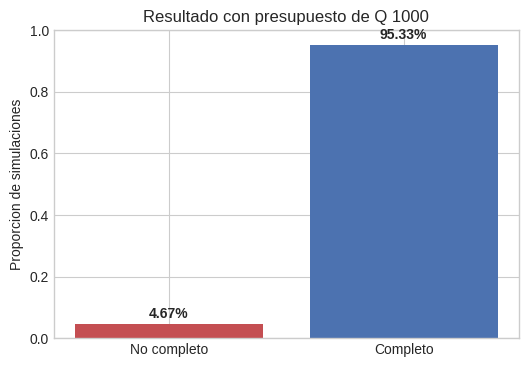

In [3]:
completo_presupuesto, sobres_presupuesto, distintas_presupuesto, repetidas_presupuesto, max_sobres_sueltos = simular_presupuesto()

prob_completar_presupuesto = completo_presupuesto.mean()
esperado_sobres = sobres_presupuesto.mean()
std_sobres = sobres_presupuesto.std(ddof=1)
fallos_presupuesto = ~completo_presupuesto
esperado_distintas_fallo = distintas_presupuesto[fallos_presupuesto].mean()

print("Resultados con sobres sueltos y presupuesto de Q 1000")
print("-" * 58)
print(f"Sobres maximos que permite el presupuesto: {max_sobres_sueltos}")
print(f"Gasto maximo si no se completa antes: Q {max_sobres_sueltos * PRECIO_SOBRE:,.2f}")
print(f"Dinero sobrante si se compran {max_sobres_sueltos} sobres: Q {PRESUPUESTO - max_sobres_sueltos * PRECIO_SOBRE:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_presupuesto:.4f} ({prob_completar_presupuesto:.2%})")
print(f"Numero esperado de sobres comprados: {esperado_sobres:.4f}")
print(f"Desviacion estandar de sobres comprados: {std_sobres:.4f}")
print(f"Simulaciones no exitosas: {fallos_presupuesto.sum()} de {R}")
print(f"Numero esperado de estampas distintas en casos no exitosos: {esperado_distintas_fallo:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["No completo", "Completo"]
proporciones = resumen_binario(completo_presupuesto)
colors = ["#c44e52", "#4c72b0"]
ax.bar(labels, proporciones, color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel("Proporcion de simulaciones")
ax.set_title("Resultado con presupuesto de Q 1000")
for idx, prop in enumerate(proporciones):
    ax.text(idx, prop + 0.02, f"{prop:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 1

1. Con Q 1000 se pueden comprar como máximo `floor(1000 / 9.50) = 105` sobres sueltos. Ese número contiene `105 * 7 = 735` estampas en total.
2. El mínimo teórico sin repetidas es `ceil(100 / 7) = 15` sobres. Por cantidad física de estampas, 105 sobres es más que suficiente; sin embargo, por las repetidas no se garantiza completar el álbum.
3. En esta simulación, aun con 105 sobres disponibles, la probabilidad estimada de completar el álbum fue aproximadamente `95.33%`, lo que muestra que el presupuesto es alto para el álbum reducido, pero no elimina por completo el riesgo de no completar.

### 3.2 Compra de una caja de 104 sobres

Ahora se compran exactamente 104 sobres por Q 975 y se verifica si el álbum queda completo al final de la caja.

Resultados comprando exactamente una caja de 104 sobres
----------------------------------------------------------
Costo de la caja: Q 975.00
Dinero sobrante respecto a Q 1000: Q 25.00
Probabilidad estimada de completar el album: 0.9482 (94.82%)
Simulaciones no exitosas: 518 de 10000
Estampas distintas promedio en casos no exitosos: 98.9788

Comparacion contra sobres sueltos con Q 1000
- Sobres sueltos: 0.9533 (95.33%)
- Caja de 104:    0.9482 (94.82%)
- Diferencia:     0.0051 puntos de probabilidad


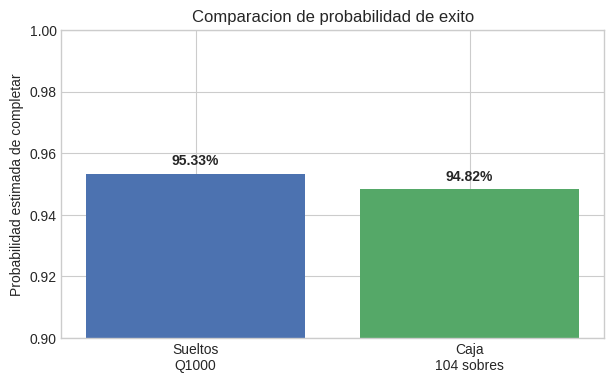

In [4]:
completo_caja, distintas_caja = simular_sobres_fijos(SOBRES_CAJA)
prob_completar_caja = completo_caja.mean()
fallos_caja = ~completo_caja

print("Resultados comprando exactamente una caja de 104 sobres")
print("-" * 58)
print(f"Costo de la caja: Q {COSTO_CAJA:,.2f}")
print(f"Dinero sobrante respecto a Q 1000: Q {PRESUPUESTO - COSTO_CAJA:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_caja:.4f} ({prob_completar_caja:.2%})")
print(f"Simulaciones no exitosas: {fallos_caja.sum()} de {R}")
print(f"Estampas distintas promedio en casos no exitosos: {distintas_caja[fallos_caja].mean():.4f}")
print()
print("Comparacion contra sobres sueltos con Q 1000")
print(f"- Sobres sueltos: {prob_completar_presupuesto:.4f} ({prob_completar_presupuesto:.2%})")
print(f"- Caja de 104:    {prob_completar_caja:.4f} ({prob_completar_caja:.2%})")
print(f"- Diferencia:     {prob_completar_presupuesto - prob_completar_caja:.4f} puntos de probabilidad")

fig, ax = plt.subplots(figsize=(7, 4))
estrategias = ["Sueltos\nQ1000", "Caja\n104 sobres"]
probabilidades = [prob_completar_presupuesto, prob_completar_caja]
ax.bar(estrategias, probabilidades, color=["#4c72b0", "#55a868"])
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Probabilidad estimada de completar")
ax.set_title("Comparacion de probabilidad de exito")
for idx, prob in enumerate(probabilidades):
    ax.text(idx, prob + 0.003, f"{prob:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 2

La caja cuesta menos por sobre (`Q 975 / 104 = Q 9.375`) que comprar sobres sueltos (`Q 9.50`). Sin embargo, la simulación de la caja usa exactamente 104 sobres, mientras que el presupuesto de Q 1000 permite comprar 105 sobres sueltos.

Con los resultados obtenidos, la caja tuvo una probabilidad estimada de completar de aproximadamente `94.82%`, mientras que comprar sobres sueltos con Q 1000 dio aproximadamente `95.33%`. Si el criterio es maximizar la probabilidad de completar el álbum, la caja sola no conviene frente a usar el presupuesto en sobres sueltos. Si el criterio incluye gastar menos, la caja es casi igual de efectiva y deja Q 25 sin usar.

### 3.3 Estrategia mixta: caja + sobres sueltos

Se analiza el dinero sobrante al comprar una caja y se propone usarlo en sobres sueltos adicionales sin exceder Q 1000.

Estrategia mixta propuesta
----------------------------------------------------------
Comprar 1 caja: 104 sobres por Q 975.00
Sobrante despues de la caja: Q 25.00
Sobres sueltos adicionales posibles: 2
Sobres totales con estrategia mixta: 106
Costo total de la estrategia mixta: Q 994.00
Presupuesto no gastado: Q 6.00
Probabilidad estimada de completar el album: 0.9567 (95.67%)
Simulaciones no exitosas: 433 de 10000
Estampas distintas promedio en casos no exitosos: 98.9861
Resumen de estrategias
Estrategia                 Sobres      Costo   Sobrante   P(completar)
------------------------------------------------------------------------
Sueltos hasta Q1000           105     997.50       2.50         0.9533
Caja sola                     104     975.00      25.00         0.9482
Caja + sueltos                106     994.00       6.00         0.9567


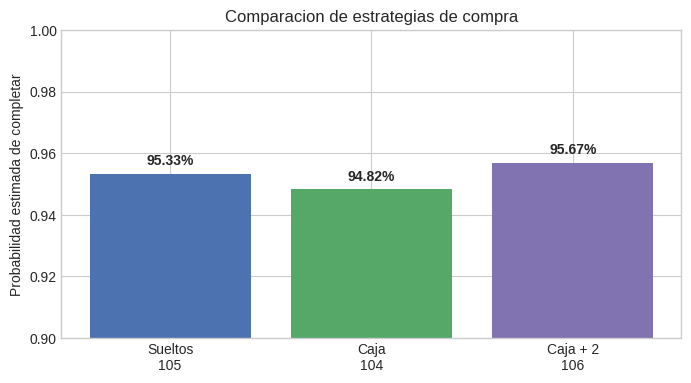

In [5]:
sobrante_caja = PRESUPUESTO - COSTO_CAJA
sobres_extra = math.floor(sobrante_caja / PRECIO_SOBRE)
sobres_mixtos = SOBRES_CAJA + sobres_extra
costo_mixto = COSTO_CAJA + sobres_extra * PRECIO_SOBRE
sobrante_mixto = PRESUPUESTO - costo_mixto

completo_mixto, distintas_mixto = simular_sobres_fijos(sobres_mixtos)
prob_completar_mixto = completo_mixto.mean()
fallos_mixto = ~completo_mixto

print("Estrategia mixta propuesta")
print("-" * 58)
print(f"Comprar 1 caja: {SOBRES_CAJA} sobres por Q {COSTO_CAJA:,.2f}")
print(f"Sobrante despues de la caja: Q {sobrante_caja:,.2f}")
print(f"Sobres sueltos adicionales posibles: {sobres_extra}")
print(f"Sobres totales con estrategia mixta: {sobres_mixtos}")
print(f"Costo total de la estrategia mixta: Q {costo_mixto:,.2f}")
print(f"Presupuesto no gastado: Q {sobrante_mixto:,.2f}")
print(f"Probabilidad estimada de completar el album: {prob_completar_mixto:.4f} ({prob_completar_mixto:.2%})")
print(f"Simulaciones no exitosas: {fallos_mixto.sum()} de {R}")
print(f"Estampas distintas promedio en casos no exitosos: {distintas_mixto[fallos_mixto].mean():.4f}")

print("Resumen de estrategias")
print(f"{'Estrategia':<24} {'Sobres':>8} {'Costo':>10} {'Sobrante':>10} {'P(completar)':>14}")
print("-" * 72)
print(f"{'Sueltos hasta Q1000':<24} {max_sobres_sueltos:>8} {max_sobres_sueltos * PRECIO_SOBRE:>10.2f} {PRESUPUESTO - max_sobres_sueltos * PRECIO_SOBRE:>10.2f} {prob_completar_presupuesto:>14.4f}")
print(f"{'Caja sola':<24} {SOBRES_CAJA:>8} {COSTO_CAJA:>10.2f} {PRESUPUESTO - COSTO_CAJA:>10.2f} {prob_completar_caja:>14.4f}")
print(f"{'Caja + sueltos':<24} {sobres_mixtos:>8} {costo_mixto:>10.2f} {sobrante_mixto:>10.2f} {prob_completar_mixto:>14.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
estrategias = ["Sueltos\n105", "Caja\n104", "Caja + 2\n106"]
probabilidades = [prob_completar_presupuesto, prob_completar_caja, prob_completar_mixto]
ax.bar(estrategias, probabilidades, color=["#4c72b0", "#55a868", "#8172b2"])
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Probabilidad estimada de completar")
ax.set_title("Comparacion de estrategias de compra")
for idx, prob in enumerate(probabilidades):
    ax.text(idx, prob + 0.003, f"{prob:.2%}", ha="center", fontweight="bold")
plt.show()

### Respuestas de análisis 3

Comprar solo la caja deja `Q 25.00` sin gastar. Como cada sobre suelto cuesta Q 9.50, ese sobrante alcanza para `2` sobres adicionales, usando Q 19.00 y dejando `Q 6.00` sin gastar.

La estrategia mixta propuesta es comprar `1 caja + 2 sobres sueltos`, para un total de `106` sobres y un costo de `Q 994.00`. Esta estrategia usa el presupuesto de forma más eficiente que la caja sola y también permite comprar un sobre más que la estrategia de sobres sueltos únicamente, que llega a 105 sobres.

En la simulación, la estrategia mixta obtuvo una probabilidad estimada de completar de aproximadamente `95.67%`, mayor que la caja sola y ligeramente mayor que comprar sobres sueltos hasta agotar el presupuesto. Por lo tanto, bajo este modelo, la estrategia mixta es la mejor de las tres para maximizar la probabilidad de completar el álbum sin exceder Q 1000.

## Etapa 4: Efecto del intercambio de repetidas

Se introduce la regla de intercambio: cada `K` estampas repetidas pueden canjearse por una estampa nueva que haga falta en el álbum. El canje se aplica después de cada sobre. Se comparan los valores `K = 1, 2, 5, 10` contra el caso base sin intercambio.

In [6]:
K_VALUES = [1, 2, 5, 10]
M_VALUES = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])
THRESHOLDS = [0.50, 0.75, 0.90]


def _comprar_sobre_vectorizado(album, banco_repetidas, k, rng, filas=None):
    """Actualiza muchas simulaciones en paralelo comprando un sobre por simulacion."""
    if filas is None:
        filas = np.arange(album.shape[0])
    filas = np.asarray(filas)
    n_filas = len(filas)

    puntajes = rng.random((n_filas, N))
    sobres = np.argpartition(puntajes, S - 1, axis=1)[:, :S]

    repetidas = album[filas[:, None], sobres].sum(axis=1)
    album[filas[:, None], sobres] = True

    if k is not None:
        banco_repetidas[filas] += repetidas
        faltantes = N - album[filas].sum(axis=1)
        canjes = np.minimum(banco_repetidas[filas] // k, faltantes)

        for q in np.unique(canjes[canjes > 0]):
            q = int(q)
            idx_local = np.flatnonzero(canjes == q)
            idx = filas[idx_local]
            faltantes_mask = ~album[idx]
            puntajes_faltantes = rng.random((len(idx), N))
            puntajes_faltantes[~faltantes_mask] = -1.0
            elegidas = np.argpartition(puntajes_faltantes, N - q, axis=1)[:, N - q:]
            album[idx[:, None], elegidas] = True
            banco_repetidas[idx] -= q * k

    return banco_repetidas


def simular_hasta_completar_intercambio(k=None, r=R, seed=SEED):
    rng = np.random.default_rng(seed)
    album = np.zeros((r, N), dtype=bool)
    banco_repetidas = np.zeros(r, dtype=int)
    sobres = np.zeros(r, dtype=int)
    completo = np.zeros(r, dtype=bool)

    while not completo.all():
        filas = np.flatnonzero(~completo)
        _comprar_sobre_vectorizado(album, banco_repetidas, k, rng, filas)
        sobres[filas] += 1
        completo[filas] = album[filas].all(axis=1)

    return sobres


def simular_curva_probabilidad_intercambio(k=None, m_values=M_VALUES, r=R, seed=SEED):
    rng = np.random.default_rng(seed)
    album = np.zeros((r, N), dtype=bool)
    banco_repetidas = np.zeros(r, dtype=int)
    probabilidades = {}
    m_set = set(int(m) for m in m_values)

    for m in range(1, int(max(m_values)) + 1):
        filas = np.flatnonzero(~album.all(axis=1))
        if len(filas) > 0:
            _comprar_sobre_vectorizado(album, banco_repetidas, k, rng, filas)
        if m in m_set:
            probabilidades[m] = float(album.all(axis=1).mean())

    return np.array([probabilidades[int(m)] for m in m_values])


def primer_m_para_umbral(probabilidades, m_values=M_VALUES, umbral=0.50):
    indices = np.flatnonzero(probabilidades >= umbral)
    if len(indices) == 0:
        return None
    return int(m_values[indices[0]])

### 4A. Simulación hasta completar el álbum para distintos K

Para cada valor de `K`, se simula el proceso hasta completar el álbum y se compara el número esperado de sobres contra el caso sin intercambio.

Parte A: sobres necesarios hasta completar el album
----------------------------------------------------------------------------
Configuracion             Media   Desv. est.    Reduccion vs. sin
----------------------------------------------------------------------------
Sin intercambio         72.0977      17.4195                0.00%
K = 1                   15.0000       0.0000               79.19%
K = 2                   19.8630       0.5425               72.45%
K = 5                   28.0691       1.4283               61.07%
K = 10                  35.1882       2.4596               51.19%


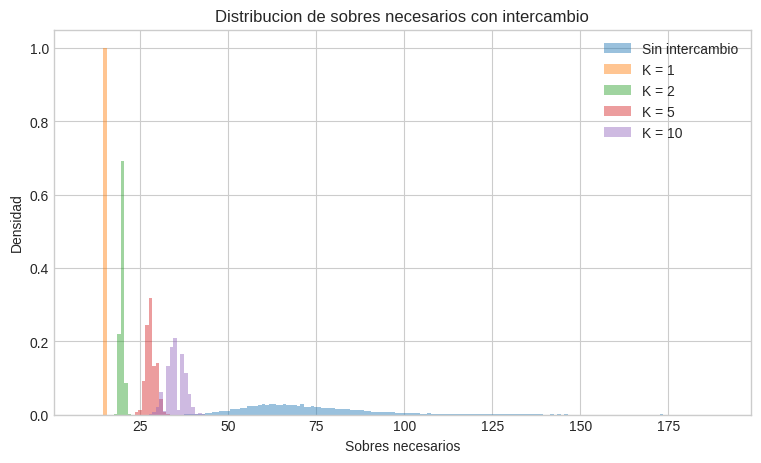

In [7]:
sobres_sin_intercambio = simular_hasta_completar_intercambio(k=None, seed=SEED)
media_sin_intercambio = sobres_sin_intercambio.mean()

resultados_k = {
    "Sin intercambio": sobres_sin_intercambio,
}
for k in K_VALUES:
    resultados_k[f"K = {k}"] = simular_hasta_completar_intercambio(k=k, seed=SEED + k)

print("Parte A: sobres necesarios hasta completar el album")
print("-" * 76)
print(f"{'Configuracion':<20} {'Media':>10} {'Desv. est.':>12} {'Reduccion vs. sin':>20}")
print("-" * 76)
for nombre, datos in resultados_k.items():
    media = datos.mean()
    desv = datos.std(ddof=1)
    reduccion = 0.0 if nombre == "Sin intercambio" else 100 * (media_sin_intercambio - media) / media_sin_intercambio
    print(f"{nombre:<20} {media:>10.4f} {desv:>12.4f} {reduccion:>19.2f}%")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(10, int(sobres_sin_intercambio.max()) + 3) - 0.5
for nombre, datos in resultados_k.items():
    ax.hist(datos, bins=bins, alpha=0.45, density=True, label=nombre)
ax.set_xlabel("Sobres necesarios")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de sobres necesarios con intercambio")
ax.legend()
plt.show()

### 4B. Probabilidad de éxito en función del número de sobres M

Para cada `K` y cada valor de `M`, se compran exactamente `M` sobres y se estima la probabilidad de completar el álbum. Se incluye la curva de referencia sin intercambio.

Parte B: probabilidad estimada de completar el album
--------------------------------------------------------------------------------------------
   M  Sin intercambio            K = 1            K = 2            K = 5           K = 10
--------------------------------------------------------------------------------------------
  20           0.0000           1.0000           0.9130           0.0000           0.0000
  25           0.0000           1.0000           1.0000           0.0201           0.0000
  30           0.0000           1.0000           1.0000           0.9496           0.0276
  35           0.0000           1.0000           1.0000           1.0000           0.6308
  40           0.0016           1.0000           1.0000           1.0000           0.9911
  45           0.0164           1.0000           1.0000           1.0000           1.0000
  50           0.0616           1.0000           1.0000           1.0000           1.0000
  55           0.1433           1.0000   

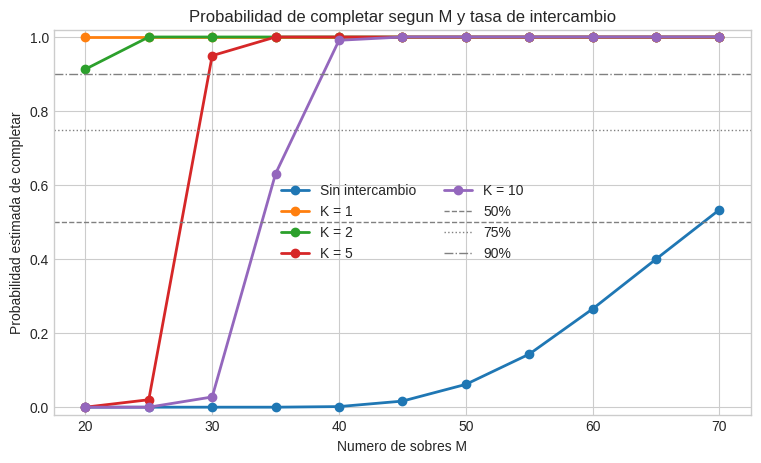

In [8]:
curvas_probabilidad = {
    "Sin intercambio": simular_curva_probabilidad_intercambio(k=None, seed=SEED),
}
for k in K_VALUES:
    curvas_probabilidad[f"K = {k}"] = simular_curva_probabilidad_intercambio(k=k, seed=SEED + 1000 * k)

print("Parte B: probabilidad estimada de completar el album")
print("-" * 92)
encabezado = f"{'M':>4} " + " ".join(f"{nombre:>16}" for nombre in curvas_probabilidad)
print(encabezado)
print("-" * 92)
for idx, m in enumerate(M_VALUES):
    fila = f"{int(m):>4} " + " ".join(f"{probs[idx]:>16.4f}" for probs in curvas_probabilidad.values())
    print(fila)

print("\nPrimer M que alcanza cada umbral")
print("-" * 76)
print(f"{'Configuracion':<20} {'50%':>10} {'75%':>10} {'90%':>10}")
print("-" * 76)
for nombre, probs in curvas_probabilidad.items():
    valores = []
    for umbral in THRESHOLDS:
        m_umbral = primer_m_para_umbral(probs, M_VALUES, umbral)
        valores.append(str(m_umbral) if m_umbral is not None else "> 70")
    print(f"{nombre:<20} {valores[0]:>10} {valores[1]:>10} {valores[2]:>10}")

fig, ax = plt.subplots(figsize=(9, 5))
for nombre, probs in curvas_probabilidad.items():
    ax.plot(M_VALUES, probs, marker="o", linewidth=2, label=nombre)
ax.axhline(0.50, color="gray", linestyle="--", linewidth=1, label="50%")
ax.axhline(0.75, color="gray", linestyle=":", linewidth=1, label="75%")
ax.axhline(0.90, color="gray", linestyle="-.", linewidth=1, label="90%")
ax.set_xlabel("Numero de sobres M")
ax.set_ylabel("Probabilidad estimada de completar")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Probabilidad de completar segun M y tasa de intercambio")
ax.legend(ncol=2)
plt.show()

### 4C. Exploración adicional de valores de K

Para responder si existe un punto de rendimientos decrecientes, se prueban valores adicionales de `K` en la simulación hasta completar el álbum.

Exploracion adicional de K
----------------------------------------------------------
     K     Media sobres    Reduccion vs. sin
----------------------------------------------------------
     1          15.0000               79.19%
     2          19.8630               72.45%
     3          23.3237               67.65%
     5          28.0691               61.07%
    10          35.1882               51.19%
    20          42.5055               41.04%
    50          52.1058               27.73%


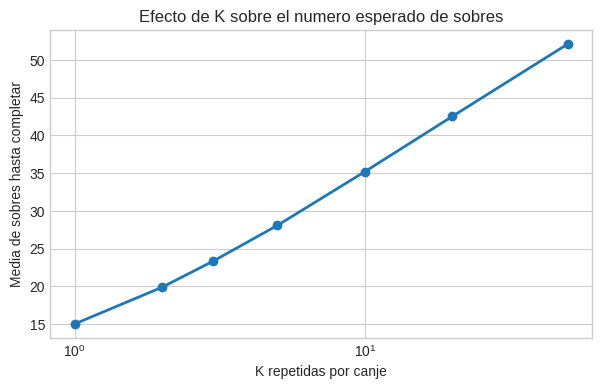

In [9]:
K_EXPLORACION = [1, 2, 3, 5, 10, 20, 50]
exploracion_k = []
for k in K_EXPLORACION:
    datos = resultados_k.get(f"K = {k}")
    if datos is None:
        datos = simular_hasta_completar_intercambio(k=k, seed=SEED + 2000 + k)
    media = datos.mean()
    reduccion = 100 * (media_sin_intercambio - media) / media_sin_intercambio
    exploracion_k.append((k, media, reduccion))

print("Exploracion adicional de K")
print("-" * 58)
print(f"{'K':>6} {'Media sobres':>16} {'Reduccion vs. sin':>20}")
print("-" * 58)
for k, media, reduccion in exploracion_k:
    print(f"{k:>6} {media:>16.4f} {reduccion:>19.2f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ks = [x[0] for x in exploracion_k]
medias = [x[1] for x in exploracion_k]
ax.plot(ks, medias, marker="o", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("K repetidas por canje")
ax.set_ylabel("Media de sobres hasta completar")
ax.set_title("Efecto de K sobre el numero esperado de sobres")
plt.show()

### Respuestas de análisis de la Etapa 4

1. Al disminuir `K`, el intercambio se vuelve más favorable y baja el número esperado de sobres necesarios. También sube la probabilidad de completar el álbum para un número fijo de sobres. La relación no es lineal: pasar de no tener intercambio a `K = 10` produce una reducción grande, y mejorar de `K = 10` a `K = 5` también ayuda bastante; pero al acercarse a `K = 1`, el beneficio se va saturando porque existe el límite mínimo de `ceil(100 / 7) = 15` sobres.

2. Para `K = 2`, la media simulada es aproximadamente `19.86` sobres. Frente al caso sin intercambio, cuya media es aproximadamente `72.10` sobres, se ahorran cerca de `52.23` sobres en promedio. A Q 9.50 por sobre, eso equivale a un ahorro aproximado de `Q 496.23`.

3. En la gráfica de probabilidad contra `M`, para `M = 45` las probabilidades con `K = 10`, `K = 5` y `K = 1` ya son prácticamente `100%`, por lo que el aumento observado entre esas tasas es `0` en ese punto. La diferencia entre tasas se aprecia mejor en valores menores de `M`, por ejemplo alrededor de `M = 30` o `M = 35`.

4. Sí hay rendimientos decrecientes. La exploración adicional muestra que mejorar tasas muy desfavorables de intercambio reduce mucho el número esperado de sobres, pero cuando `K` ya es pequeño, especialmente entre `K = 2` y `K = 1`, el beneficio adicional queda limitado por el mínimo físico de sobres necesarios. La razón es que aunque el intercambio elimine casi todo el efecto de las repetidas, todavía se necesitan suficientes estampas totales para cubrir las 100 posiciones del álbum.

5. Si se reparte el costo de un sobre entre sus 7 estampas, el costo contable por estampa es `Q 9.50 / 7 ≈ Q 1.36`. Entonces una estampa nueva obtenida por canje de `K` repetidas tiene un costo efectivo aproximado de `K * Q 9.50 / 7`. Bajo esta interpretación: `K = 1` cuesta cerca de `Q 1.36`, `K = 2` cerca de `Q 2.71`, `K = 5` cerca de `Q 6.79` y `K = 10` cerca de `Q 13.57` por estampa nueva canjeada. La tasa más rentable sería `K = 1`. En efectivo adicional, el canje cuesta Q 0 una vez que las repetidas ya existen, pero esas repetidas provienen de sobres previamente pagados.